Modeling dataset: 170,782 rows × 7 features

📊 MODEL PERFORMANCE:
  Mean Absolute Error (MAE): 0.33 days
  R² Score:                  0.9226

  Interpretation:
  → On average, our delay predictions are off by 0.3 days
  → The model explains 92.3% of delay variance

📋 COEFFICIENT INTERPRETATION:
                    Feature  Coefficient
   schedule_adherence_ratio     1.848348
          ship_mode_encoded     0.863305
             market_encoded     0.001550
           revenue_per_unit    -0.000449
              is_high_value    -0.000622
        order_item_quantity    -0.001466
days_for_shipment_scheduled    -0.164837


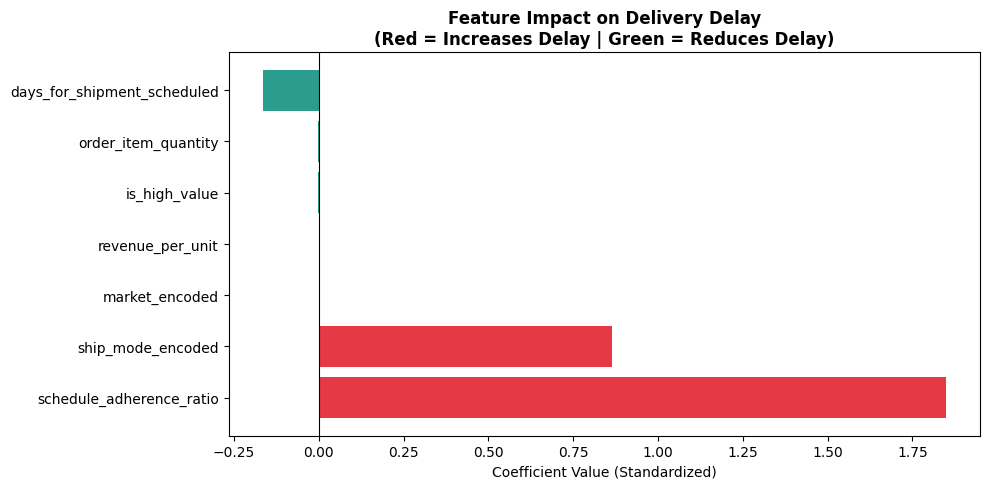

In [5]:
# LINEAR REGRESSION — Predicting Delivery Delay

import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.preprocessing import StandardScaler

df = pd.read_csv('../data/cleaned/supply_chain_features.csv')

# ─── Define Features & Target ───────────────────────────────

features = [
    'days_for_shipment_scheduled',  # Operational input
    'ship_mode_encoded',            # Logistics choice
    'order_item_quantity',          # Volume stress
    'is_high_value',                # Priority flag
    'market_encoded',               # Geographic factor
    'revenue_per_unit',             # Product value signal
    'schedule_adherence_ratio'      # Historical performance
]

target = 'delay_days'

model_df = df[features + [target]].dropna()

X = model_df[features]
y = model_df[target]

print(f"Modeling dataset: {X.shape[0]:,} rows × {X.shape[1]} features")

# ─── Train/Test Split ───────────────────────────────────────
# 80% train, 20% test

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

# ─── Scale Features ─────────────────────────────────────────
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# ─── Train Model ────────────────────────────────────────────
model = LinearRegression()
model.fit(X_train_scaled, y_train)

# ─── Evaluate ───────────────────────────────────────────────
y_pred = model.predict(X_test_scaled)

mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"\n📊 MODEL PERFORMANCE:")
print(f"  Mean Absolute Error (MAE): {mae:.2f} days")
print(f"  R² Score:                  {r2:.4f}")
print(f"\n  Interpretation:")
print(f"  → On average, our delay predictions are off by {mae:.1f} days")
print(f"  → The model explains {r2*100:.1f}% of delay variance")

# ─── Coefficient Interpretation ─────────────────────────────

coef_df = pd.DataFrame({
    "Feature" : features,
    'Coefficient' : model.coef_
}).sort_values('Coefficient', ascending=False)

print("\n📋 COEFFICIENT INTERPRETATION:")
print(coef_df.to_string(index=False))

# ─── Visualize Coefficients ─────────────────────────────────
plt.figure(figsize=(10, 5))
colors = ['#E63946' if c > 0 else '#2A9D8F' for c in coef_df['Coefficient']]
plt.barh(coef_df['Feature'], coef_df['Coefficient'], color=colors)
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Feature Impact on Delivery Delay\n(Red = Increases Delay | Green = Reduces Delay)',
          fontsize=12, fontweight='bold')
plt.xlabel('Coefficient Value (Standardized)')
plt.tight_layout()
plt.savefig('../docs/regression_coefficients.png', dpi=150, bbox_inches='tight')
plt.show()